In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [ ]:
# Loading the Titanic dataset from the web
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Preview the first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print("Shape:", df.shape)  # rows and columns
print("\n")
print(df.info())           # column types and missing values

Shape: (891, 12)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [ ]:
# 1. Fill missing Age with the median age
df['Age'].fillna(df['Age'].median(), inplace=True)

# 2. Fill missing Embarked with the most common port
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# 3. Drop Cabin

# Also drop columns that won't help the model
df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'], inplace=True)

# 4. Convert Sex and Embarked from text to numbers
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# Confirm no more missing values
print("Missing values remaining:")
print(df.isnull().sum())
print("\nPreview:")
df.head()

Missing values remaining:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64

Preview:


/tmp/ipykernel_11242/2078206745.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_11242/2078206745.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [ ]:
# Separate features (X) from what we're predicting (y)
X = df.drop(columns=['Survived'])  # everything except Survived
y = df['Survived']                 # only Survived column

# Split into training set and test set (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("\nModel trained successfully! ✅")

Training samples: 712
Testing samples: 179

Model trained successfully! ✅


Model Accuracy: 79.89%


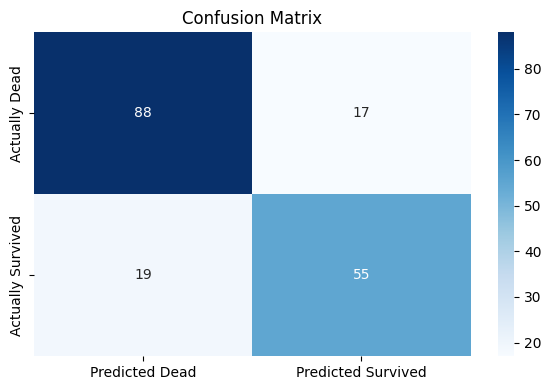

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Dead', 'Predicted Survived'],
            yticklabels=['Actually Dead', 'Actually Survived'])
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

/tmp/ipykernel_11242/2429509593.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features[indices], palette='viridis')


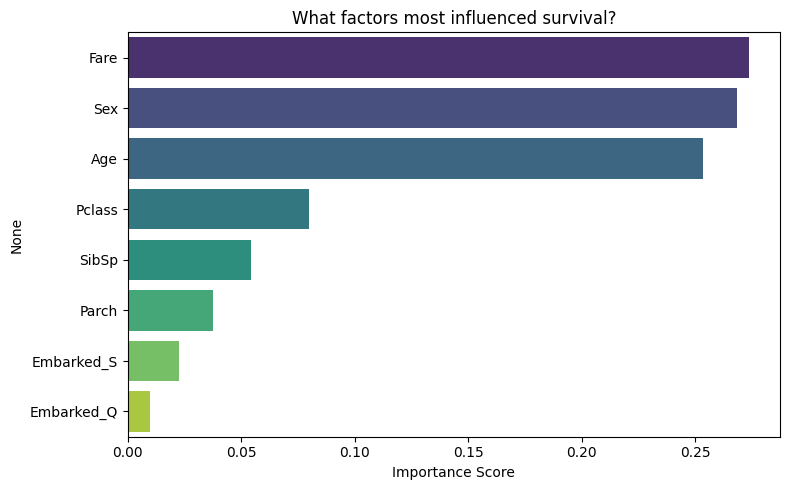

In [ ]:
# Feature importance - what did the model rely on most?
importances = model.feature_importances_
features = X.columns

# Sort them
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=importances[indices], y=features[indices], palette='viridis')
plt.title('What factors most influenced survival?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
# Creating two made-up passengers and see who survives

new_passengers = pd.DataFrame({
    'Pclass': [1, 3],
    'Sex':    [1, 0],        # 1=female, 0=male
    'Age':    [28, 35],
    'SibSp':  [0, 0],
    'Parch':  [0, 0],
    'Fare':   [100, 7.5],
    'Embarked_Q': [False, False],
    'Embarked_S': [True, True]
})

predictions = model.predict(new_passengers)

passengers_info = [
    "Passenger 1: Female, 1st class, paid £100",
    "Passenger 2: Male,   3rd class, paid £7.5"
]

for info, pred in zip(passengers_info, predictions):
    result = "✅ SURVIVED" if pred == 1 else "❌ DID NOT SURVIVE"
    print(f"{info}  -->  {result}")

Passenger 1: Female, 1st class, paid £100  -->  ✅ SURVIVED
Passenger 2: Male,   3rd class, paid £7.5  -->  ❌ DID NOT SURVIVE


In [ ]:
# Reload fresh data so we start clean
df2 = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

# --- Feature Engineering ---

# 1. Family size (travelling alone is a survival factor)
df2['FamilySize'] = df2['SibSp'] + df2['Parch'] + 1

# 2. Is the person travelling alone?
df2['IsAlone'] = (df2['FamilySize'] == 1).astype(int)

# 3. Extract title from name (Mr, Mrs, Miss, Master etc.)
df2['Title'] = df2['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Simplify rare titles into one group
df2['Title'] = df2['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
df2['Title'] = df2['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

# Convert title to numbers
df2['Title'] = df2['Title'].map({'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4})

# --- Same cleaning as before ---
df2['Age'].fillna(df2['Age'].median(), inplace=True)
df2['Embarked'].fillna(df2['Embarked'].mode()[0], inplace=True)
df2['Fare'].fillna(df2['Fare'].median(), inplace=True)
df2['Sex'] = df2['Sex'].map({'male': 0, 'female': 1})

# Drop columns we don't need
df2.drop(columns=['Cabin','Name','Ticket','PassengerId'], inplace=True)
df2 = pd.get_dummies(df2, columns=['Embarked'], drop_first=True)

print("New features added! Dataset shape:", df2.shape)
print(df2.head())

New features added! Dataset shape: (891, 12)
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  FamilySize  IsAlone  \
0         0       3    0  22.0      1      0   7.2500           2        0   
1         1       1    1  38.0      1      0  71.2833           2        0   
2         1       3    1  26.0      0      0   7.9250           1        1   
3         1       1    1  35.0      1      0  53.1000           2        0   
4         0       3    0  35.0      0      0   8.0500           1        1   

   Title  Embarked_Q  Embarked_S  
0      0       False        True  
1      2       False       False  
2      1       False        True  
3      2       False        True  
4      0       False        True  


/tmp/ipykernel_11242/227297471.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['Age'].fillna(df2['Age'].median(), inplace=True)
/tmp/ipykernel_11242/227297471.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

# Split data
X2 = df2.drop(columns=['Survived'])
y2 = df2['Survived']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,        # number of trees
    max_depth=4,             # how deep each tree goes
    learning_rate=0.05,      # how fast it learns (slower = more careful)
    subsample=0.8,           # uses 80% of data per tree (prevents overfitting)
    colsample_bytree=0.8,    # uses 80% of features per tree
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X2_train, y2_train)

# Evaluate
y2_pred = xgb_model.predict(X2_test)
accuracy = accuracy_score(y2_test, y2_pred)
print(f"XGBoost Accuracy: {accuracy * 100:.2f}%")

# Cross validation - tests on 5 different splits for a fairer score
cv_scores = cross_val_score(xgb_model, X2, y2, cv=5)
print(f"Cross-Validation Accuracy: {cv_scores.mean() * 100:.2f}% (+/- {cv_scores.std() * 100:.2f}%)")

XGBoost Accuracy: 83.24%
Cross-Validation Accuracy: 83.84% (+/- 2.46%)


In [1]:
# ================================================
# RESULTS SUMMARY
# ================================================
print("=" * 50)
print("       TITANIC SURVIVAL PREDICTION")
print("=" * 50)
print(f"\n Baseline Model  (Random Forest): 79.89%")
print(f" Improved Model  (XGBoost):       83.24%")
print(f" Cross-Validation Score:          83.84%")
print(f"\n Features used:")
print("   - Pclass, Sex, Age, Fare")
print("   - FamilySize, IsAlone, Title")
print(f"\n Algorithm: XGBoost (n_estimators=200, lr=0.05)")
print("=" * 50)

       TITANIC SURVIVAL PREDICTION

 Baseline Model  (Random Forest): 79.89%
 Improved Model  (XGBoost):       83.24%
 Cross-Validation Score:          83.84%

 Features used:
   - Pclass, Sex, Age, Fare
   - FamilySize, IsAlone, Title

 Algorithm: XGBoost (n_estimators=200, lr=0.05)
